In [42]:
#QForte & Qiskit
import qiskit as qk
import qforte as qf

#QForte objects needed for tutorial
from qforte import Circuit

#QForte-Qiskit API
from qforte.qiskit_api.translators import qforte_to_qiskit
from qforte.qiskit_api.dispatchers import QpuDispatcher
from qforte.qiskit_api.dispatchers import AerDispatcher

#Qiskit objects needed for tutorial
from qiskit import QuantumCircuit
from qiskit.visualization import plot_histogram

#Qiskit Runtime Service needed for IBM auth & session management
from qiskit_ibm_runtime import QiskitRuntimeService 
import qiskit_ibm_runtime.accounts.exceptions.AccountNotFoundError as NoAccount

ModuleNotFoundError: No module named 'qiskit_ibm_runtime.accounts.exceptions.AccountNotFoundError'; 'qiskit_ibm_runtime.accounts.exceptions' is not a package

This is a tutorial on how to use the QForte Qiskit API. 
Let's first import QForte, Qiskit, and the 

You probably want to use this run jobs on IBM Quantum Cloud.
To do this, you need an IBMid, and then you can create an "instance" through IBM Quantum Platform.
Once you have done this, you can create an API key on IBM Quantum Platform to access your instance.

You can use the QiskitRuntimeService to save your credentials on disk in your home directory.
Let's proceed:

In [44]:
try:
    QiskitRuntimeService()
    print("IBM Quantum Platform credentials found!")
except:
    print("IBM Quantum Platform credentials not found. Enter them in the input fields to get started: ")
    QiskitRuntimeService.save_account(
        token=input("Enter your IBM Quantum Platoform API Key: "),
        name=input("Enter your IBMid account name: "),
        instance=input("Enter your IBM Quantum Platform instance name: "),
        set_as_default=True,
        overwrite=True,
)

IBM Quantum Platform credentials not found. Enter them in the input fields to get started: 


Enter your IBM Quantum Platoform API Key:  iG73gMNVQjWwV2sjEZd0_7QxAo9mVE2pv3xtFeOYmxpT
Enter your IBMid account name:  cspreen@proton.me
Enter your IBM Quantum Platform instance name:  open-instance


Okay, now that we have access to the IBM Quantum Platform, let's start by making a Bell State in QForte and then converting it to an equivalent Qiskit object.

In [45]:
# Create a Bell state in QForte
qf_bell = qf.Circuit()
qf_bell.add_gate(qf.gate('H', 0))
qf_bell.add_gate(qf.gate('cX', 1 , 0))

# Create a Bell state circuit in Qiskit
qc_bell = QuantumCircuit(2, 2)
qc_bell.h(0)
qc_bell.cx(0, 1)

# Translate the QForte circuit to Qiskit
trans_bell = qforte_to_qiskit(qf_bell, 2)

# Check for equivalence
if qk.quantum_info.Operator(trans_bell).equiv(qc_bell):
    print("Translated circuit is equivalent to native Qiskit circuit!\n")

# Add a measurement gate
trans_bell.measure_all()
print(trans_bell)

Translated circuit is equivalent to native Qiskit circuit!

        ┌───┐      ░ ┌─┐   
   q_0: ┤ H ├──■───░─┤M├───
        └───┘┌─┴─┐ ░ └╥┘┌─┐
   q_1: ─────┤ X ├─░──╫─┤M├
             └───┘ ░  ║ └╥┘
meas: 2/══════════════╩══╩═
                      0  1 


Now that we have translated QForte's representation of the Bell State to its Qiskit equivalent, let's sample this state.

The QForte Qiskit API provides a batteries-included solution for sampling and estimation: the Dispatcher class.

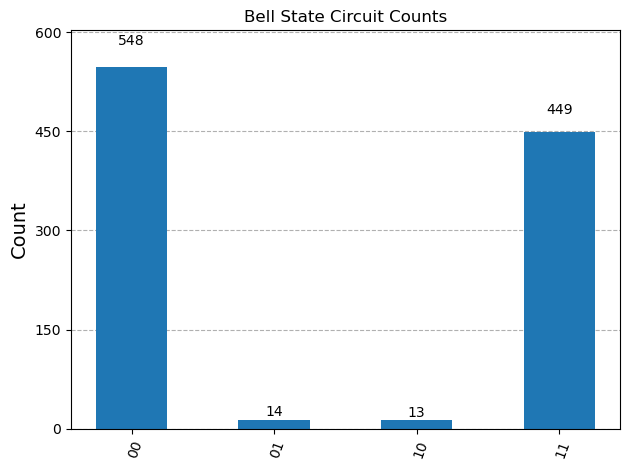

In [46]:
# Create a QpuDispatcher
qpu_dispatcher = QpuDispatcher()

# Dispatch the sampling job on Qpu
qpu_result_bell = qpu_dispatcher.dispatch_sampler(circuits=[trans_bell], shots=1024)
   
# Plot the results
plot_histogram(qpu_result_bell[0].data.meas.get_counts(), title="Bell State Circuit Counts")

We can also sample from the Aer quantum simulator from the qiskit_aer package, by using the AerDispatcher.

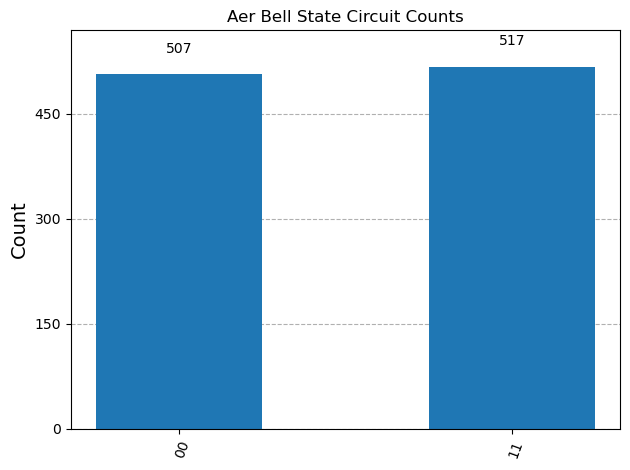

In [10]:
# Create a QpuDispatcher
aer_dispatcher = AerDispatcher()

# Dispatch the sampling job on Aer
aer_result_bell = aer_dispatcher.dispatch_sampler(circuits=[qc_bell], shots=1024)

# Plot the results
plot_histogram(aer_result_bell[0].data.meas.get_counts(), title="Aer Bell State Circuit Counts")

We can also use the Dispatchers to perform observable estimation: